# Module Description

# Multi-Channel Mixed Data

## Data to Analyse

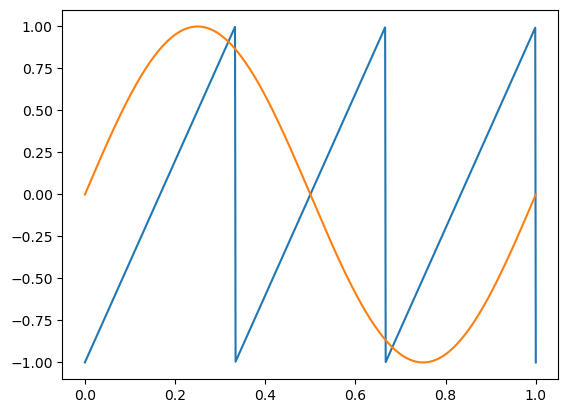

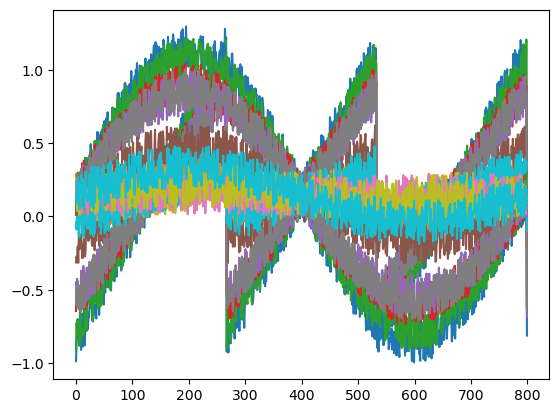

In [36]:
import numpy as np
from datagen import paperExamplegen, paperExamplegen2
data,t = paperExamplegen(20)
#data,t = paperExamplegen2(20)
import matplotlib.pyplot as plt
plt.figure()
plt.plot(data)

## Ranking

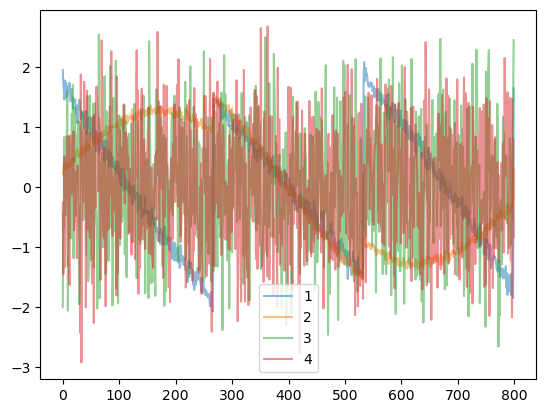

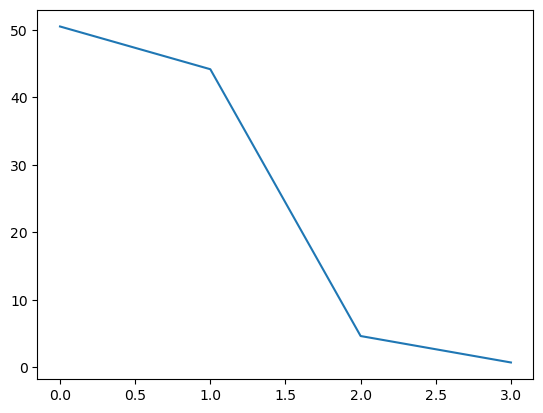

In [37]:
from functions import hankelize
from functions import prebuiltICA,innerProduct
import LSPIE 

ranker = LSPIE.processor("LR",prebuiltICA,innerProduct)
ranker.fit(data,4,False)

i = 0
for component in ranker.components:
    i = 1+i
    plt.plot(component,label = i,alpha = 0.5)
plt.legend()

plt.figure()
plt.plot(ranker.scores)

## Scaling

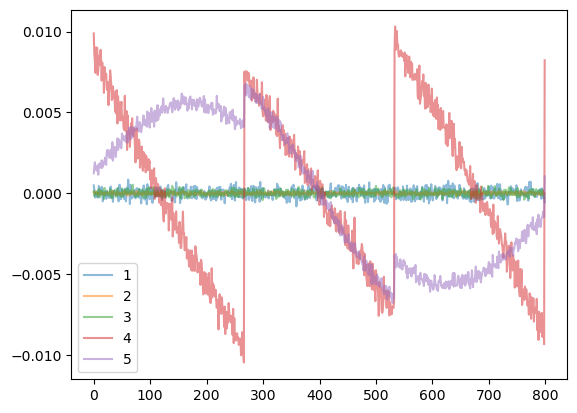

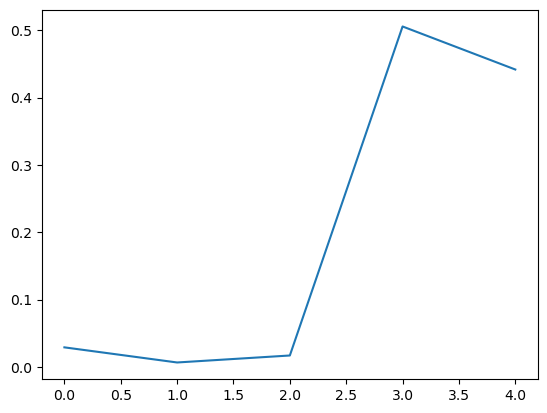

In [38]:
from functions import hankelize
from functions import prebuiltICA,innerProduct
import LSPIE 
scaler = LSPIE.processor("LS",prebuiltICA,innerProduct)
scaler.fit(data,5,False)

i = 0
for component in scaler.components:
    i = 1+i
    plt.plot(component,label = i,alpha = 0.5)
plt.legend()

plt.figure()
plt.plot(scaler.scores)


## Ranked Scaling

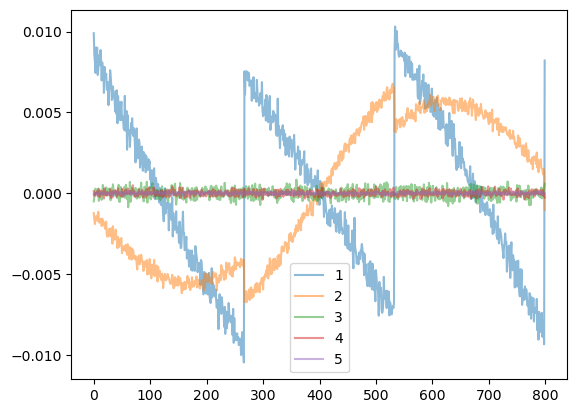

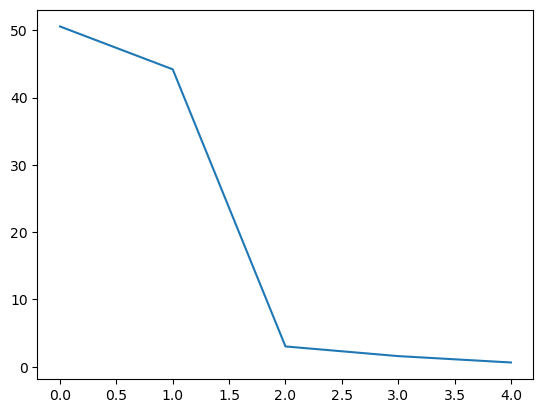

In [39]:
from functions import hankelize
from functions import prebuiltICA,innerProduct
import LSPIE 
rankedscaler = LSPIE.processor("LRS",prebuiltICA,innerProduct)
rankedscaler.fit(data,5,False)

i = 0
for component in rankedscaler.components:
    i = 1+i
    plt.plot(component,label = i,alpha = 0.5)
plt.legend()

plt.figure()
plt.plot(rankedscaler.scores)


## Clustering

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


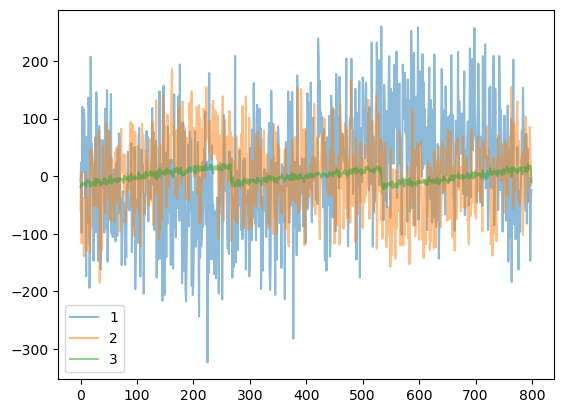

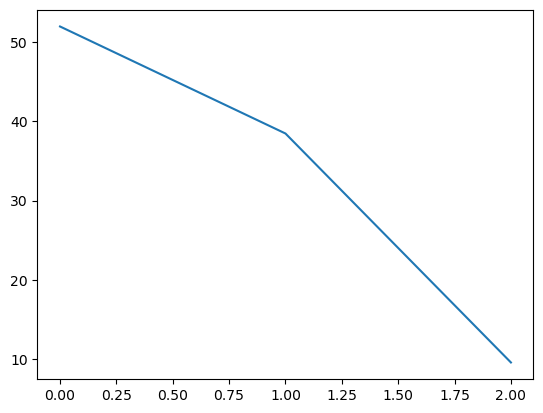

In [40]:
from functions import prebuiltICA,innerProduct,absInnerProduct
import LSPIE 

clustering = LSPIE.processor("LC",prebuiltICA,absInnerProduct)

from sklearn.cluster import Birch ,DBSCAN # type: ignore
#help(Birch)

hank = False
lvm = prebuiltICA
metric = absInnerProduct
n = 3
cmodel = Birch(n_clusters = n)


clustering.fit(data,n,cmodel,hank)

i = 0
for component in clustering.components:
    i = 1+i
    plt.plot(component,label = i,alpha = 0.5)
plt.legend()

plt.figure()
plt.plot(clustering.scores)



## Condensing

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\decomposition\_fastica.py:598: UserWarning: n_components is too large: it will be set to 20
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


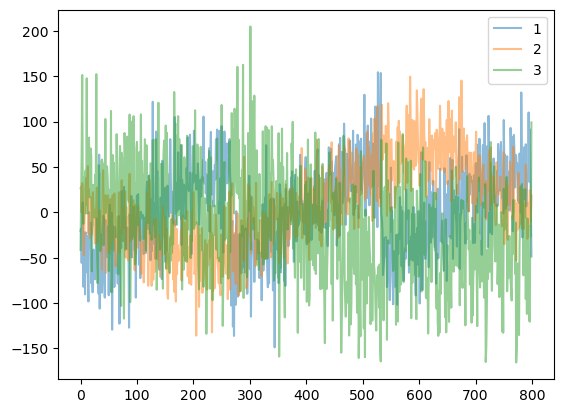

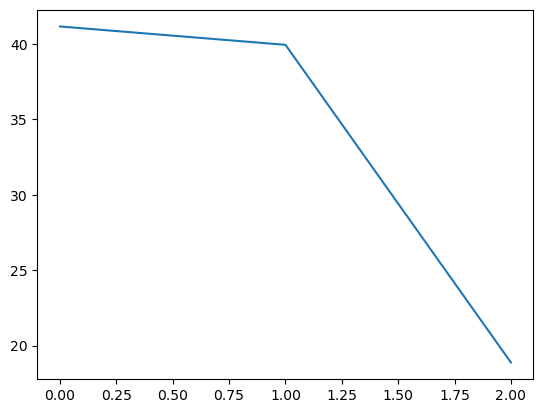

In [41]:
from functions import prebuiltICA,innerProduct,absInnerProduct
import LSPIE 

condensing = LSPIE.processor("LCON",prebuiltICA,absInnerProduct)

from sklearn.cluster import Birch ,DBSCAN # type: ignore
#help(Birch)

hank = False
lvm = prebuiltICA
metric = absInnerProduct
n = 3
cmodel = Birch(n_clusters = n)


condensing.fit(data,cmodel,1,hank)

i = 0
for component in condensing.components:
    i = 1+i
    plt.plot(component,label = i,alpha = 0.5)
plt.legend()

plt.figure()
plt.plot(condensing.scores)


## Expansion

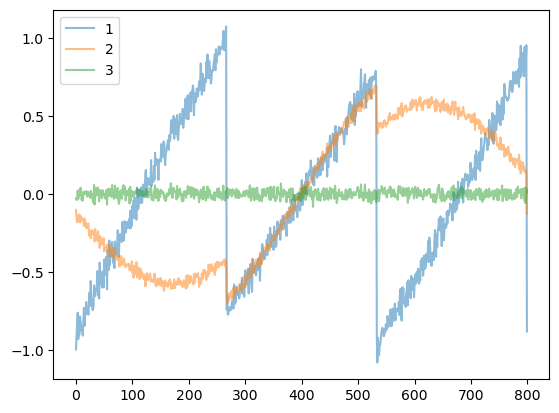

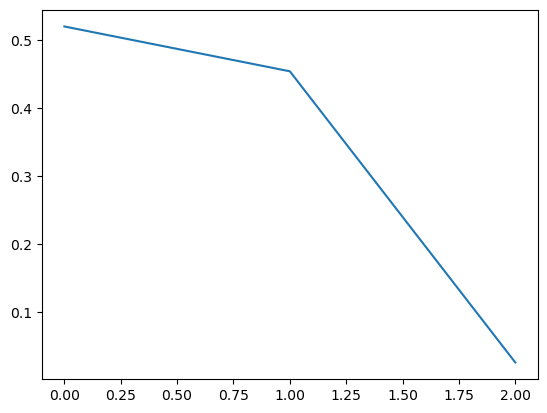

In [42]:
from functions import prebuiltICA,innerProduct,absInnerProduct
import LSPIE 

expansion = LSPIE.processor("LEXP",prebuiltICA,absInnerProduct)

from sklearn.cluster import Birch ,DBSCAN # type: ignore
#help(Birch)

maxcomp = 300
cutoff = 0.1

expansion.fit(data,maxcomp,cutoff,hank)

i = 0
for component in expansion.components:
    i = 1+i
    plt.plot(component,label = i,alpha = 0.5)
plt.legend()

plt.figure()
plt.plot(expansion.scores)

# Real World Example

In [43]:
# import necessary libraries
import pandas as pd
import os
import glob
  
  
# use glob to get all the csv files 
# in the folder
path = r"C:\Work\Doctoral Research\LSPIE Redone\EKG Data for Masters"
print(path)
csv_files = glob.glob(os.path.join(path, "*.csv"))
  # loop over the list of csv files
for f in csv_files:
      
    # read the csv file
    df = pd.read_csv(f)
      
    # print the location and filename
    print('Location:', f)
    print('File Name:', f.split("\\")[-1])
      
    # print the content
    print('Content:')
    display(df)
    print()
  


C:\Work\Doctoral Research\LSPIE Redone\EKG Data for Masters
Location: C:\Work\Doctoral Research\LSPIE Redone\EKG Data for Masters\mitbih_test.csv
File Name: mitbih_test.csv
Content:


,1.000000000000000000e+00,7.582644820213317871e-01,1.115702465176582336e-01,0.000000000000000000e+00,8.057851344347000122e-02,7.851240038871765137e-02,6.611569970846176147e-02,4.958677664399147034e-02,4.752065986394882202e-02,3.512396663427352905e-02,...,0.000000000000000000e+00.56,0.000000000000000000e+00.57,0.000000000000000000e+00.58,0.000000000000000000e+00.59,0.000000000000000000e+00.60,0.000000000000000000e+00.61,0.000000000000000000e+00.62,0.000000000000000000e+00.63,0.000000000000000000e+00.64,0.000000000000000000e+00.65
0,0.908425,0.783883,0.531136,0.362637,0.366300,0.344322,0.333333,0.307692,0.296703,0.300366,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.730088,0.212389,0.000000,0.119469,0.101770,0.101770,0.110619,0.123894,0.115044,0.132743,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.910417,0.681250,0.472917,0.229167,0.068750,0.000000,0.004167,0.014583,0.054167,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.570470,0.399329,0.238255,0.147651,0.000000,0.003356,0.040268,0.080537,0.070470,0.090604,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.000000,0.923664,0.656489,0.195929,0.111959,0.175573,0.122137,0.050891,0.035623,0.055980,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21886,0.928736,0.871264,0.804598,0.742529,0.650575,0.535632,0.394253,0.250575,0.140230,0.102299,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
21887,0.802691,0.692078,0.587444,0.446936,0.318386,0.189836,0.118087,0.077728,0.112108,0.152466,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
21888,1.000000,0.967359,0.620178,0.347181,0.139466,0.089021,0.103858,0.100890,0.106825,0.100890,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
21889,0.984127,0.567460,0.607143,0.583333,0.607143,0.575397,0.575397,0.488095,0.392857,0.238095,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0



Location: C:\Work\Doctoral Research\LSPIE Redone\EKG Data for Masters\mitbih_train.csv
File Name: mitbih_train.csv
Content:


,9.779411554336547852e-01,9.264705777168273926e-01,6.813725233078002930e-01,2.450980395078659058e-01,1.544117629528045654e-01,1.911764740943908691e-01,1.519607901573181152e-01,8.578431606292724609e-02,5.882352963089942932e-02,4.901960864663124084e-02,...,0.000000000000000000e+00.79,0.000000000000000000e+00.80,0.000000000000000000e+00.81,0.000000000000000000e+00.82,0.000000000000000000e+00.83,0.000000000000000000e+00.84,0.000000000000000000e+00.85,0.000000000000000000e+00.86,0.000000000000000000e+00.87,0.000000000000000000e+00.88
0,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.927461,1.000000,0.626943,0.193437,0.094991,0.072539,0.043178,0.053541,0.093264,0.189983,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87548,0.807018,0.494737,0.536842,0.529825,0.491228,0.484211,0.456140,0.396491,0.284211,0.136842,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
87549,0.718333,0.605000,0.486667,0.361667,0.231667,0.120000,0.051667,0.001667,0.000000,0.013333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
87550,0.906122,0.624490,0.595918,0.575510,0.530612,0.481633,0.444898,0.387755,0.322449,0.191837,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
87551,0.858228,0.645570,0.845570,0.248101,0.167089,0.131646,0.121519,0.121519,0.118987,0.103797,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0



Location: C:\Work\Doctoral Research\LSPIE Redone\EKG Data for Masters\ptbdb_abnormal.csv
File Name: ptbdb_abnormal.csv
Content:


,9.322328567504882812e-01,8.696785569190979004e-01,8.861859440803527832e-01,9.296264052391052246e-01,9.087749719619750977e-01,9.339704513549804688e-01,8.010425567626953125e-01,7.497828006744384766e-01,6.872285008430480957e-01,6.350998878479003906e-01,...,0.000000000000000000e+00.117,0.000000000000000000e+00.118,0.000000000000000000e+00.119,0.000000000000000000e+00.120,0.000000000000000000e+00.121,0.000000000000000000e+00.122,0.000000000000000000e+00.123,0.000000000000000000e+00.124,0.000000000000000000e+00.125,1.000000000000000000e+00.1
0,1.000000,0.606941,0.384181,0.254237,0.223567,0.276836,0.253430,0.184826,0.153349,0.121872,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.000000,0.951613,0.923963,0.853303,0.791859,0.734255,0.672043,0.685100,0.670507,0.667435,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.977819,0.899261,0.230129,0.032348,0.142329,0.223660,0.328096,0.367837,0.381701,0.389094,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.935618,0.801661,0.805815,1.000000,0.722741,0.480789,0.454829,0.319834,0.266874,0.308411,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.925265,0.433352,0.073620,0.079197,0.136643,0.182934,0.182934,0.182376,0.196877,0.203569,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10500,0.981409,1.000000,0.559171,0.287093,0.196639,0.204862,0.215946,0.243833,0.242760,0.250268,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10501,0.906250,0.922379,0.878024,0.810484,0.712702,0.667339,0.608871,0.527218,0.480847,0.442540,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10502,1.000000,0.867971,0.674122,0.470332,0.296987,0.169307,0.077664,0.081392,0.074868,0.089779,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10503,1.000000,0.984672,0.658888,0.556394,0.446809,0.395790,0.315260,0.276367,0.261039,0.258522,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0



Location: C:\Work\Doctoral Research\LSPIE Redone\EKG Data for Masters\ptbdb_normal.csv
File Name: ptbdb_normal.csv
Content:


,1.000000000000000000e+00,9.003241658210754395e-01,3.585899472236633301e-01,5.145867168903350830e-02,4.659643396735191345e-02,1.268233358860015869e-01,1.333063244819641113e-01,1.191247999668121338e-01,1.106158867478370667e-01,1.130470037460327148e-01,...,0.000000000000000000e+00.56,0.000000000000000000e+00.57,0.000000000000000000e+00.58,0.000000000000000000e+00.59,0.000000000000000000e+00.60,0.000000000000000000e+00.61,0.000000000000000000e+00.62,0.000000000000000000e+00.63,0.000000000000000000e+00.64,0.000000000000000000e+00.65
0,1.000000,0.794681,0.375387,0.116883,0.000000,0.171923,0.283859,0.293754,0.325912,0.345083,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.909029,0.791482,0.423169,0.186712,0.000000,0.007836,0.063032,0.077002,0.074957,0.077342,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.478893,0.056760,0.064176,0.081289,0.072732,0.055619,0.048774,0.054478,0.041643,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.000000,0.867238,0.201360,0.099349,0.141336,0.120934,0.108516,0.096393,0.093436,0.100828,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.948983,0.505265,0.004176,0.022513,0.059550,0.107298,0.110385,0.111293,0.116558,0.118192,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4040,1.000000,0.929586,0.503550,0.293491,0.169822,0.159763,0.130769,0.125444,0.137278,0.111243,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4041,1.000000,0.637579,0.154837,0.061983,0.088965,0.083374,0.065143,0.057365,0.060039,0.060039,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4042,1.000000,0.872574,0.465071,0.232212,0.126132,0.155886,0.174644,0.190168,0.203752,0.168823,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4043,0.915983,0.529373,0.288406,0.144536,0.171802,0.180669,0.177566,0.176458,0.178896,0.180448,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [44]:
listOfFiles = []
for f in csv_files:     
    # read the csv file
    # print the location and filename
    fileName = f.split("\\")[-1]
    listOfFiles.append(fileName)
print(listOfFiles)
listOfdataFrames = {}

['mitbih_test.csv', 'mitbih_train.csv', 'ptbdb_abnormal.csv', 'ptbdb_normal.csv']


In [45]:
   totalData = {}

for f in csv_files:
      
    # read the csv file
    df = pd.read_csv(f)
    fileName = f.split("\\")[-1]
    name = fileName[:-4]
    # print the location and filename
    print(name)
    totalData[name] = df


mitbih_test
mitbih_train
ptbdb_abnormal
ptbdb_normal


In [46]:
totalData.keys()
keys = []
for key in totalData.keys():
    keys.append(key)
print(keys)
key = keys[1]
print(key)
data = totalData[key]
data

['mitbih_test', 'mitbih_train', 'ptbdb_abnormal', 'ptbdb_normal']
mitbih_train


,9.779411554336547852e-01,9.264705777168273926e-01,6.813725233078002930e-01,2.450980395078659058e-01,1.544117629528045654e-01,1.911764740943908691e-01,1.519607901573181152e-01,8.578431606292724609e-02,5.882352963089942932e-02,4.901960864663124084e-02,...,0.000000000000000000e+00.79,0.000000000000000000e+00.80,0.000000000000000000e+00.81,0.000000000000000000e+00.82,0.000000000000000000e+00.83,0.000000000000000000e+00.84,0.000000000000000000e+00.85,0.000000000000000000e+00.86,0.000000000000000000e+00.87,0.000000000000000000e+00.88
0,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.927461,1.000000,0.626943,0.193437,0.094991,0.072539,0.043178,0.053541,0.093264,0.189983,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87548,0.807018,0.494737,0.536842,0.529825,0.491228,0.484211,0.456140,0.396491,0.284211,0.136842,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
87549,0.718333,0.605000,0.486667,0.361667,0.231667,0.120000,0.051667,0.001667,0.000000,0.013333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
87550,0.906122,0.624490,0.595918,0.575510,0.530612,0.481633,0.444898,0.387755,0.322449,0.191837,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
87551,0.858228,0.645570,0.845570,0.248101,0.167089,0.131646,0.121519,0.121519,0.118987,0.103797,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0


In [47]:
help(plt.plot)

Help on function plot in module matplotlib.pyplot:

plot(
    *args: 'float | ArrayLike | str',
    scalex: 'bool' = True,
    scaley: 'bool' = True,
    data=None,
    **kwargs
) -> 'list[Line2D]'
    Plot y versus x as lines and/or markers.

    Call signatures::

        plot([x], y, [fmt], *, data=None, **kwargs)
        plot([x], y, [fmt], [x2], y2, [fmt2], ..., **kwargs)

    The coordinates of the points or line nodes are given by *x*, *y*.

    The optional parameter *fmt* is a convenient way for defining basic
    formatting like color, marker and linestyle. It's a shortcut string
    notation described in the *Notes* section below.

    >>> plot(x, y)        # plot x and y using default line style and color
    >>> plot(x, y, 'bo')  # plot x and y using blue circle markers
    >>> plot(y)           # plot y using x as index array 0..N-1
    >>> plot(y, 'r+')     # ditto, but with red plusses

    You can use `.Line2D` properties as keyword arguments for more
    control on th

['mitbih_test', 'mitbih_train', 'ptbdb_abnormal', 'ptbdb_normal']
ptbdb_normal


Text(0.5, 1.0, 'ptbdb_normal 678')

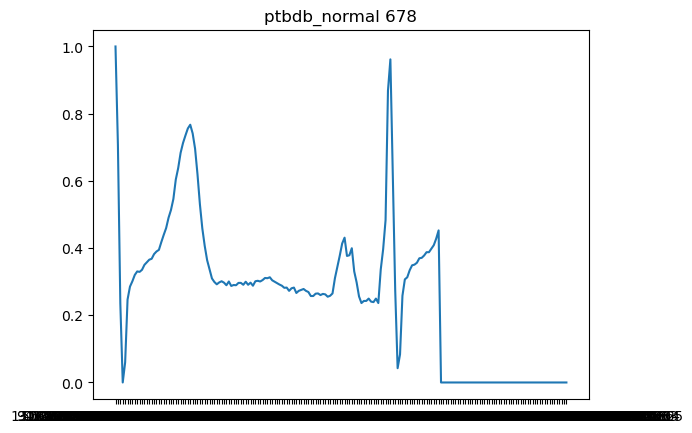

In [48]:
totalData.keys()
keys = []
for key in totalData.keys():
    keys.append(key)
print(keys)
key = keys[3]
print(key)
data = totalData[key]
n = 678
h = 80

plt.plot(data.iloc[n])
plt.title(key +" " + str(n))

In [49]:
totalData.keys()
keys = []
for key in totalData.keys():
    keys.append(key)
print(keys)
key = keys[3]
print(key)
data = totalData[key]
#n = 4567

normal = data
normkey = key




['mitbih_test', 'mitbih_train', 'ptbdb_abnormal', 'ptbdb_normal']
ptbdb_normal


In [50]:
totalData.keys()
keys = []
for key in totalData.keys():
    keys.append(key)
print(keys)
key = keys[2]
print(key)
data = totalData[key]
#n = 4567

abnormal = data
abkey = key




['mitbih_test', 'mitbih_train', 'ptbdb_abnormal', 'ptbdb_normal']
ptbdb_abnormal


## Ranked Scaling

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


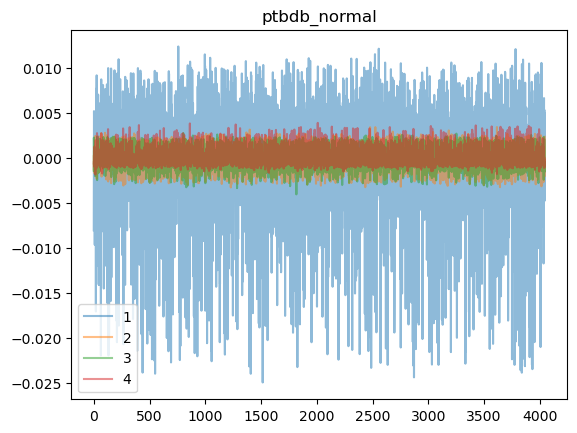

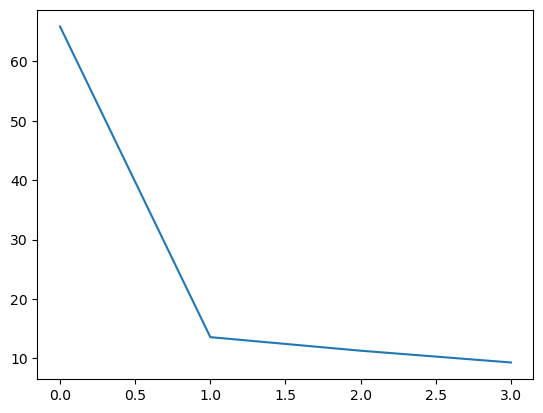

In [51]:
from functions import hankelize
from functions import prebuiltICA,innerProduct
import LSPIE 

ranker = LSPIE.processor("LRS",prebuiltICA,innerProduct)
ranker.fit(normal,4,False)

i = 0
for component in ranker.components:
    i = 1+i
    plt.plot(component,label = i,alpha = 0.5)
plt.legend()
plt.title(normkey)
plt.figure()
plt.plot(ranker.scores)

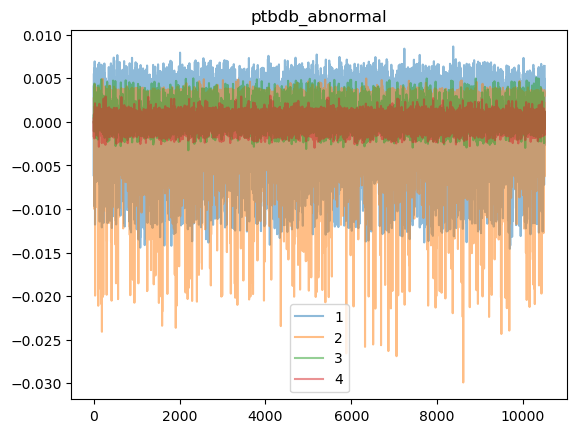

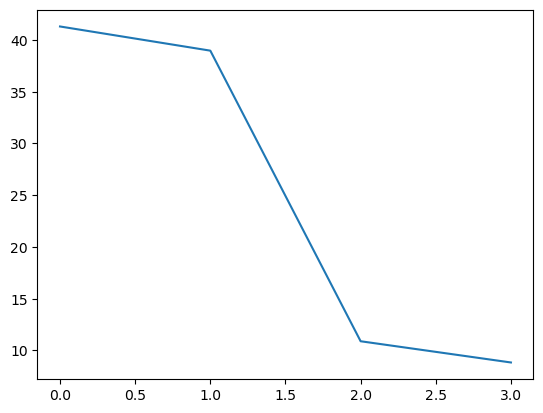

In [52]:
from functions import hankelize
from functions import prebuiltICA,innerProduct
import LSPIE 

ranker = LSPIE.processor("LRS",prebuiltICA,innerProduct)
ranker.fit(abnormal,4,False)

i = 0
for component in ranker.components:
    i = 1+i
    plt.plot(component,label = i,alpha = 0.5)
plt.legend()
plt.title(abkey)
plt.figure()
plt.plot(ranker.scores)

## Expansion

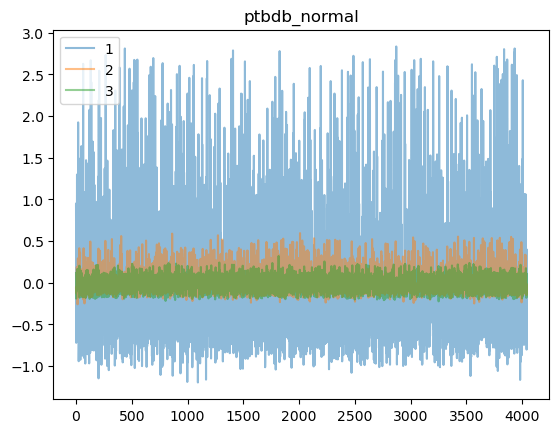

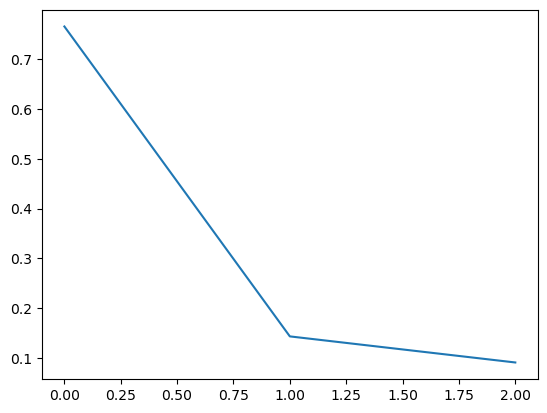

In [58]:
from functions import hankelize
from functions import prebuiltICA,innerProduct
import LSPIE 

lexp = LSPIE.processor("LEXP",prebuiltICA,innerProduct)
lexp.fit(normal,5,0.1,False)

i = 0
for component in lexp.components:
    i = 1+i
    plt.plot(component,label = i,alpha = 0.5)
plt.legend()
plt.title(normkey)
plt.figure()
plt.plot(lexp.scores)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


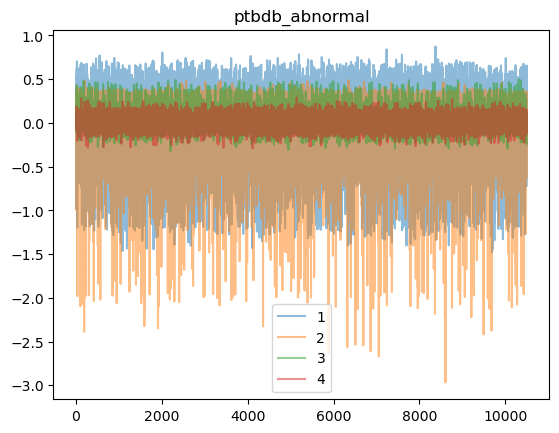

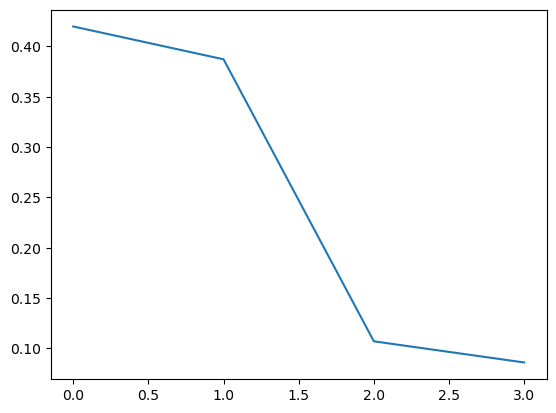

In [54]:
from functions import hankelize
from functions import prebuiltICA,innerProduct
import LSPIE 

lexp = LSPIE.processor("LEXP",prebuiltICA,innerProduct)
lexp.fit(abnormal,5,0.1,False)

i = 0
for component in lexp.components:
    i = 1+i
    plt.plot(component,label = i,alpha = 0.5)
plt.legend()
plt.title(abkey)
plt.figure()
plt.plot(lexp.scores)

## Condensing

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\decomposition\_fastica.py:598: UserWarning: n_components is too large: it will be set to 188
  warnings.warn(


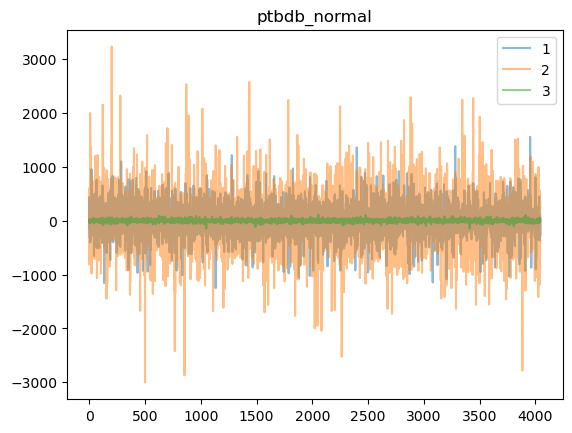

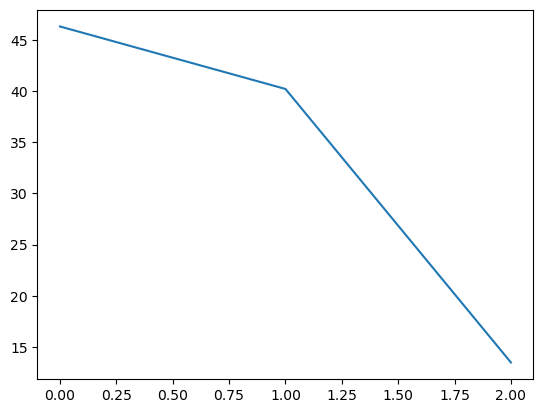

In [59]:
from functions import prebuiltICA,innerProduct,absInnerProduct
import LSPIE 

condensing = LSPIE.processor("LCON",prebuiltICA,absInnerProduct)

from sklearn.cluster import Birch ,DBSCAN # type: ignore
#help(Birch)

hank = False
lvm = prebuiltICA
metric = absInnerProduct
n = 3
cmodel = Birch(n_clusters = n)


condensing.fit(normal,cmodel,1,hank)

i = 0
for component in condensing.components:
    i = 1+i
    plt.plot(component,label = i,alpha = 0.5)
plt.legend()
plt.title(normkey)
plt.figure()
plt.plot(condensing.scores)


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\decomposition\_fastica.py:598: UserWarning: n_components is too large: it will be set to 188
  warnings.warn(


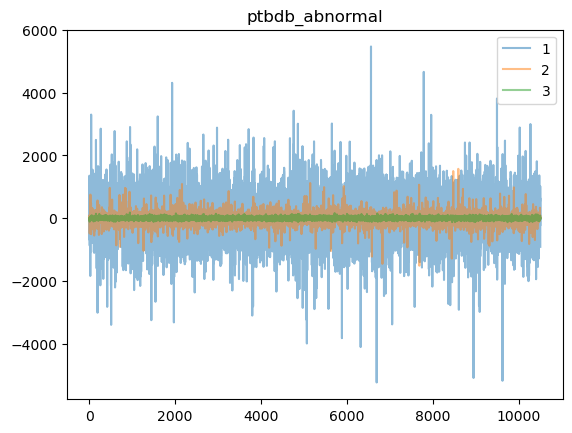

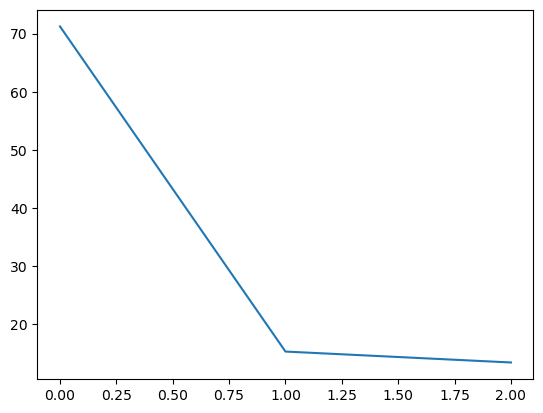

In [60]:
from functions import prebuiltICA,innerProduct,absInnerProduct
import LSPIE 

condensing = LSPIE.processor("LCON",prebuiltICA,absInnerProduct)

from sklearn.cluster import Birch ,DBSCAN # type: ignore
#help(Birch)

hank = False
lvm = prebuiltICA
metric = absInnerProduct
n = 3
cmodel = Birch(n_clusters = n)


condensing.fit(abnormal,cmodel,1,hank)

i = 0
for component in condensing.components:
    i = 1+i
    plt.plot(component,label = i,alpha = 0.5)
plt.legend()
plt.title(abkey)
plt.figure()
plt.plot(condensing.scores)
